<a href="https://colab.research.google.com/github/Maryjancy894/INTERNSHIP/blob/main/salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np

# Number of rows
rows = 250

# Random seed
np.random.seed(42)

# Generate data
employee_id = range(1, rows + 1)

age = np.random.randint(21, 50, rows)

gender = np.random.choice(['Male', 'Female'], rows)

education = np.random.choice(
    ['UG', 'PG', 'PhD'],
    rows,
    p=[0.5, 0.4, 0.1]
)

department = np.random.choice(
    ['HR', 'IT', 'Sales', 'Finance'],
    rows
)

experience = np.random.randint(1, 20, rows)

working_hours = np.random.randint(35, 60, rows)

performance_score = np.random.randint(1, 10, rows)

projects_completed = np.random.randint(1, 15, rows)

# Salary logic
salary = (
    experience * 5000 +
    performance_score * 3000 +
    projects_completed * 2000 +
    np.random.randint(10000, 30000, rows)
)

# Create dataframe
df = pd.DataFrame({
    'Employee_ID': employee_id,
    'Age': age,
    'Gender': gender,
    'Education': education,
    'Department': department,
    'Experience': experience,
    'Working_Hours': working_hours,
    'Performance_Score': performance_score,
    'Projects_Completed': projects_completed,
    'Salary': salary
})

# Save CSV
df.to_csv("employee_salary_dataset.csv", index=False)

print("Dataset Created Successfully!")
df.head()

Dataset Created Successfully!


,Employee_ID,Age,Gender,Education,Department,Experience,Working_Hours,Performance_Score,Projects_Completed,Salary
0,1,27,Female,PG,Finance,7,54,8,12,106125
1,2,40,Female,UG,HR,17,43,3,14,135216
2,3,49,Male,PG,IT,7,51,8,9,89113
3,4,35,Female,PG,HR,12,54,5,1,97238
4,5,31,Male,UG,IT,17,56,1,13,137760


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode categorical columns
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])

# Features and target
X = df.drop('Salary', axis=1)
y = df['Salary']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Preprocessing Completed!")

Employee_ID           0
Age                   0
Gender                0
Education             0
Department            0
Experience            0
Working_Hours         0
Performance_Score     0
Projects_Completed    0
Salary                0
dtype: int64
Preprocessing Completed!


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 4767.694923410993
MSE: 31654572.75263773
R2 Score: 0.9667827056867948


In [5]:
def salary_category(salary):

    if salary > 120000:
        return "High"

    elif salary > 80000:
        return "Medium"

    else:
        return "Low"

df['Salary_Category'] = df['Salary'].apply(salary_category)

df.head()

,Employee_ID,Age,Gender,Education,Department,Experience,Working_Hours,Performance_Score,Projects_Completed,Salary,Salary_Category
0,1,27,0,0,0,7,54,8,12,106125,Medium
1,2,40,0,2,1,17,43,3,14,135216,High
2,3,49,1,0,2,7,51,8,9,89113,Medium
3,4,35,0,0,1,12,54,5,1,97238,Medium
4,5,31,1,2,2,17,56,1,13,137760,High


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Features
X = df.drop(['Salary', 'Salary_Category'], axis=1)

# Target
y = df['Salary_Category']

# Scaling
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Model
log_model = LogisticRegression()

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.92
[[14  0  2]
 [ 0 18  1]
 [ 0  1 14]]


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features
X_rf = df.drop(['Salary', 'Salary_Category'], axis=1)

# Target (numerical Salary for Regression)
y_rf = df['Salary']

# Scaling
scaler_rf = StandardScaler()
X_scaled_rf = scaler_rf.fit_transform(X_rf)

# Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_scaled_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

# Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train_rf, y_train_rf)

# Predict
y_pred_rf = rf.predict(X_test_rf)

print("Random Forest Completed")

Random Forest Completed


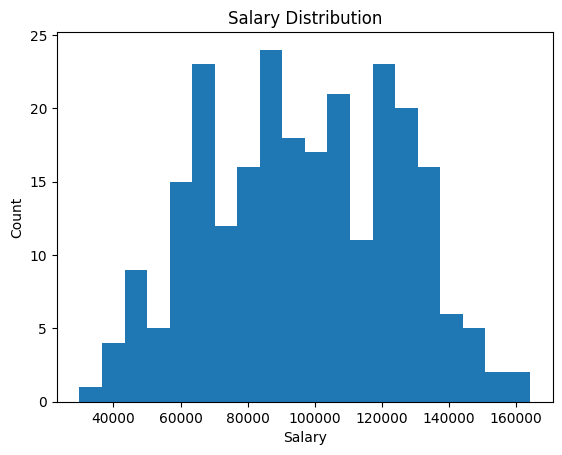

In [9]:
plt.hist(df['Salary'], bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

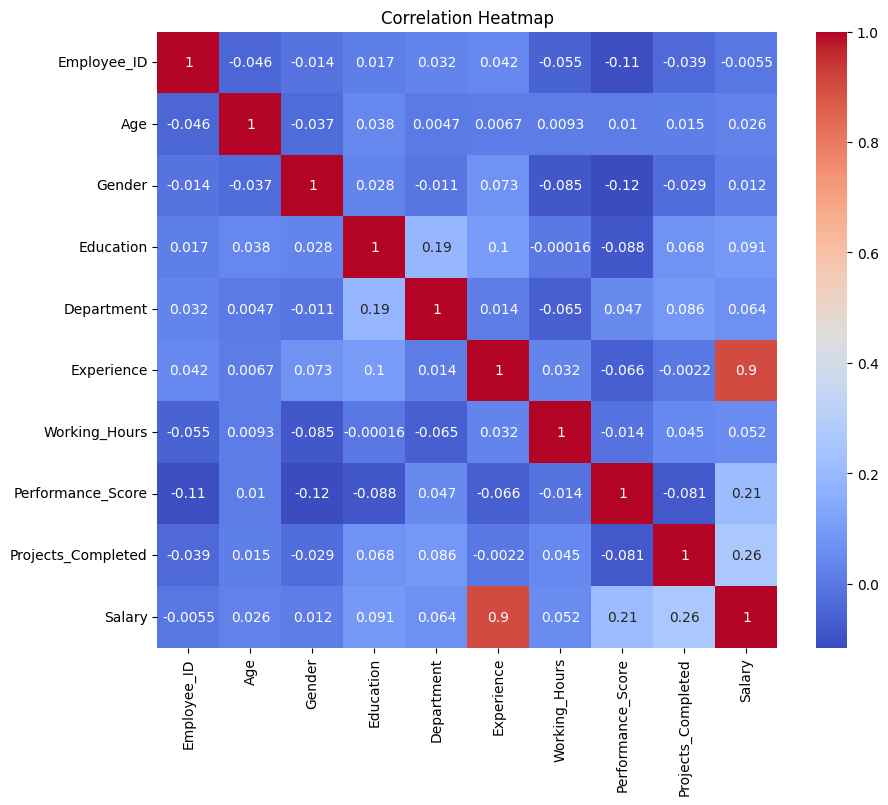

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

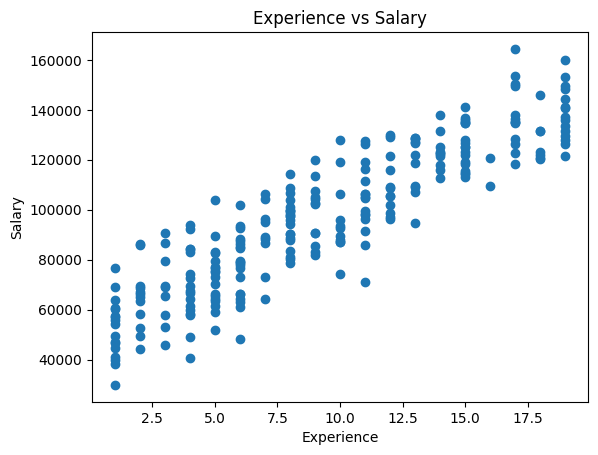

In [11]:
plt.scatter(df['Experience'], df['Salary'])

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.title("Experience vs Salary")

plt.show()

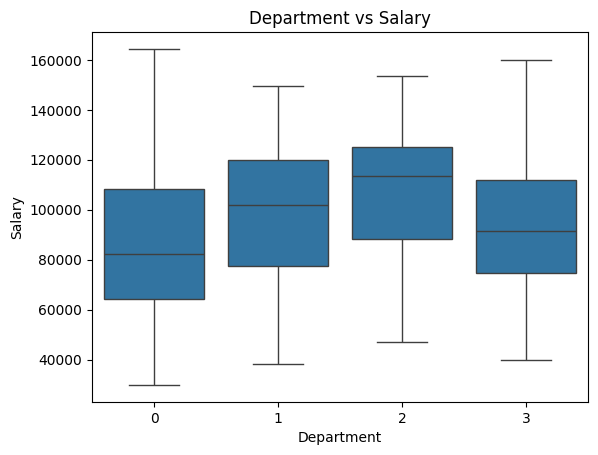

In [12]:
sns.boxplot(
    x='Department',
    y='Salary',
    data=df
)

plt.title("Department vs Salary")

plt.show()

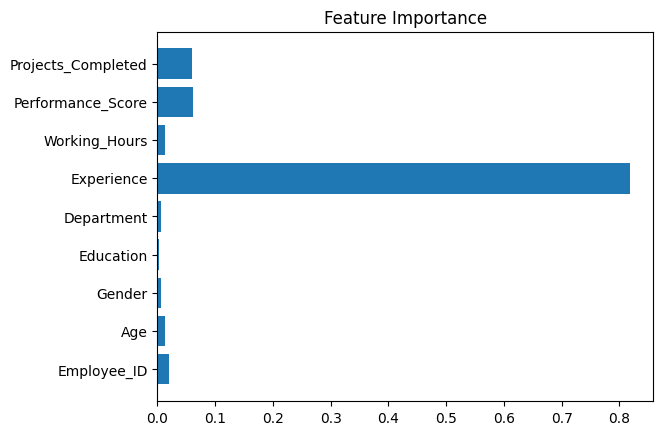

In [13]:
importance = rf.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()